In [ ]:

!pip install -q tensorflow numpy pandas matplotlib

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib

import random
import os

random.seed(42)

np.random.seed(42)

tf.random.set_seed(42)

os.environ['PYTHONHASHSEED'] = '42'

"""
Seed Explanation:
- random.seed(42): Python ke random module ko control karta hai
- np.random.seed(42): NumPy ke random values fix karta hai
- tf.random.set_seed(42): TensorFlow operations reproducible banata hai
- PYTHONHASHSEED: hashing randomness ko fix karta hai

In sab ko set karne se har run me same results milte hain (reproducibility).
"""


print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)


gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\n✅ GPU Available:")
    for gpu in gpus:
        print(gpu)
else:
    print("\n❌ No GPU detected")

    """
    Why CPU training is slower:
    - CPU me limited cores hote hain (8-16 approx), GPU me thousands cores hote hain
    - Deep learning me large matrix operations hoti hain jo parallel compute hoti hain
    - CPU sequential processing karta hai, GPU parallel → isliye GPU fast hota hai

    What I would do on a GPU machine:
    - CUDA-enabled GPU use karta
    - Larger batch size use karta
    - Training speed kaafi fast ho jati (hours → minutes)
    - Multiple experiments jaldi run kar pata
    """


TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0

✅ GPU Available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min: 0 max: 255

CIFAR dtype: uint8
CIFAR min: 0 max: 255

MNIST Class Distribution:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples

Dataset is approximately balanced


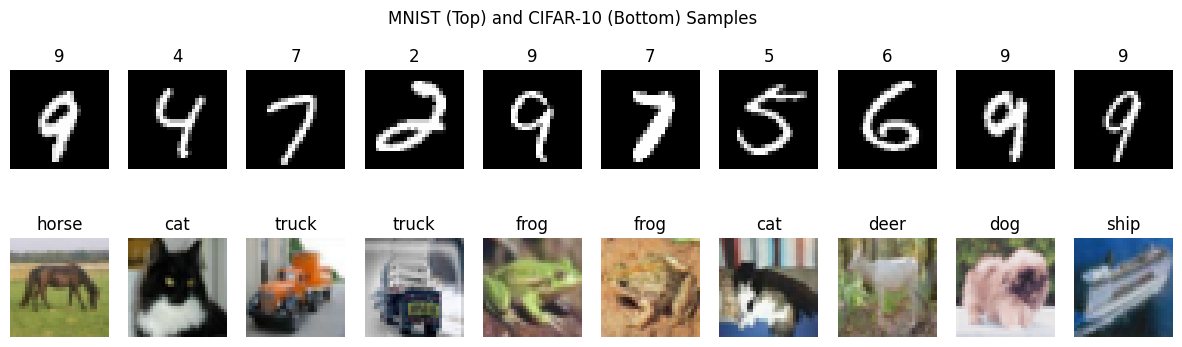


✅ Image saved as dataset_samples.png


In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()


print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Train Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)


print("\nMNIST dtype:", x_train_mnist.dtype)
print("MNIST min:", x_train_mnist.min(), "max:", x_train_mnist.max())

print("\nCIFAR dtype:", x_train_cifar.dtype)
print("CIFAR min:", x_train_cifar.min(), "max:", x_train_cifar.max())


unique, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

if len(set(counts)) == 1:
    print("\nDataset is perfectly balanced")
else:
    print("\nDataset is approximately balanced")

cifar_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

mnist_indices = random.sample(range(len(x_train_mnist)), 10)
cifar_indices = random.sample(range(len(x_train_cifar)), 10)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(mnist_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(f"{y_train_mnist[idx]}")
    plt.axis('off')

for i, idx in enumerate(cifar_indices):
    plt.subplot(2, 10, 10+i+1)
    plt.imshow(x_train_cifar[idx])
    label = y_train_cifar[idx][0]
    plt.title(cifar_classes[label])
    plt.axis('off')

plt.suptitle("MNIST (Top) and CIFAR-10 (Bottom) Samples")

plt.savefig("dataset_samples.png")
plt.show()

print("\n✅ Image saved as dataset_samples.png")

In [ ]:


import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


def preprocess(images, labels):

    print("===== BEFORE PROCESSING =====")
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Pixel range:", images.min(), "to", images.max())
    print("Sample pixels:", images[0][0][:5])

    images = images.astype(np.float32) / 255.0

    print("\nAfter Normalisation:")
    print("dtype:", images.dtype)
    print("range:", images.min(), "to", images.max())
    print("Sample pixels:", images[0][0][:5])

    images = np.expand_dims(images, axis=-1)

    print("\nAfter Reshaping:")
    print("New shape:", images.shape)

    labels = tf.keras.utils.to_categorical(labels, num_classes=10)

    print("\nAfter One-hot Encoding:")
    print("Label shape:", labels.shape)
    print("Sample label:", labels[0])

    return images, labels


x_train_processed, y_train_processed = preprocess(x_train, y_train)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
===== BEFORE PROCESSING =====
Image shape: (60000, 28, 28)
Label shape: (60000,)
Image dtype: uint8
Pixel range: 0 to 255
Sample pixels: [0 0 0 0 0]

After Normalisation:
dtype: float32
range: 0.0 to 1.0
Sample pixels: [0. 0. 0. 0. 0.]

After Reshaping:
New shape: (60000, 28, 28, 1)

After One-hot Encoding:
Label shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


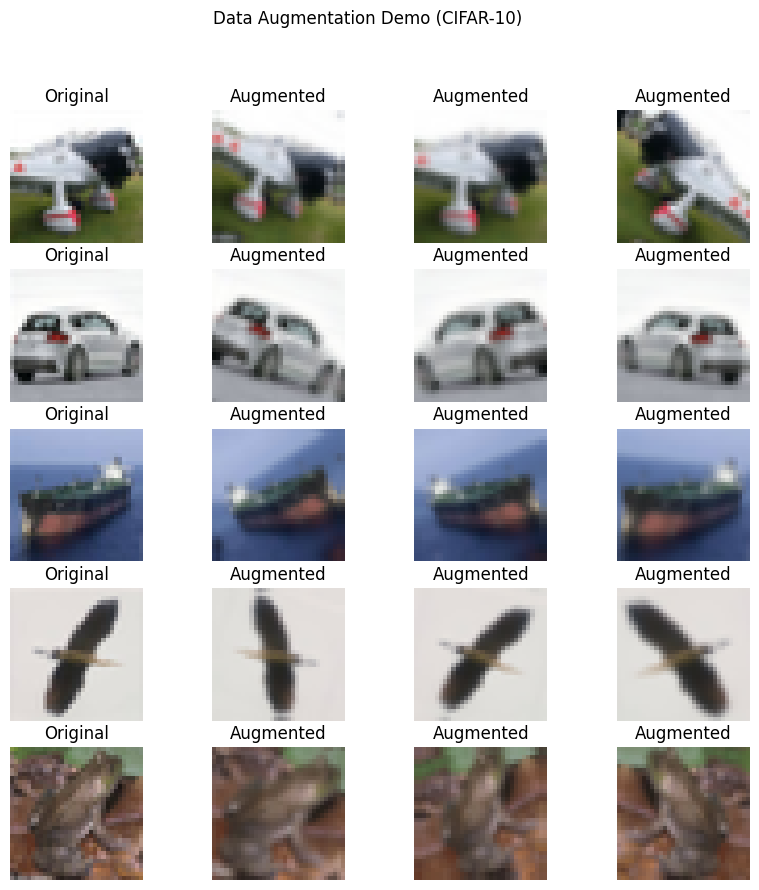

✅ Image saved as augmentation_demo.png


In [ ]:
# ===============================
# Problem 4: Data Augmentation Pipeline
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# ===============================
# Load CIFAR-10 dataset
# ===============================
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# ===============================
# Define Augmentation Pipeline
# ===============================

data_augmentation = tf.keras.Sequential([

    # (a) Horizontal Flip (50% probability automatically handled)
    tf.keras.layers.RandomFlip("horizontal"),

    # (b) Random Rotation (±10 degrees → 10/180 approx)
    tf.keras.layers.RandomRotation(0.1),

    # (c) Random Zoom (up to 10%)
    tf.keras.layers.RandomZoom(0.1)
])

# ===============================
# Select 5 random images
# ===============================

indices = random.sample(range(len(x_train)), 5)

# ===============================
# Plot 5x4 grid (Original + 3 Augmented)
# ===============================

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices):

    original = x_train[idx]

    # Column 1 → Original
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis('off')

    # Columns 2,3,4 → Augmented versions
    for j in range(3):
        augmented = data_augmentation(tf.expand_dims(original, axis=0))
        augmented = tf.squeeze(augmented).numpy().astype("uint8")

        plt.subplot(5, 4, i*4 + (j+2))
        plt.imshow(augmented)
        plt.title("Augmented")
        plt.axis('off')

plt.suptitle("Data Augmentation Demo (CIFAR-10)")

# Save image
plt.savefig("augmentation_demo.png")
plt.show()

print("✅ Image saved as augmentation_demo.png")

Answer of Question 1(Task-1)

In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of feature channels present in each image.

For a grayscale image, there is only one channel (C = 1) because each pixel contains a single intensity value representing brightness. For example, MNIST images have shape (28, 28, 1).
For an RGB image, there are three channels (C = 3) corresponding to the Red, Green, and Blue components. Each pixel is represented by three values, one for each color channel. For example, CIFAR-10 images have shape (32, 32, 3).

Thus, the channel dimension encodes the depth of information per pixel, either as intensity (grayscale) or color components (RGB).

Answer of Q2(Task-1)

Training a CNN on large images such as 1024×1024 satellite images can lead to memory issues. The following strategies can be used to manage memory efficiently:

Image Resizing / Downsampling
The input images can be resized to a smaller resolution (e.g., 256×256). This reduces the number of pixels and therefore decreases memory usage and computation cost, while still preserving important features.
Batch-wise Data Loading (Data Generators)
Instead of loading the entire dataset into memory, data can be loaded in small batches using generators (e.g., tf.data or PyTorch DataLoader). This ensures that only a portion of the dataset is in memory at any given time.
Patch-based Training (Tiling)
Large images can be divided into smaller patches (e.g., 256×256 crops), and the model can be trained on these patches. This allows handling high-resolution images without exceeding memory limits.

These techniques help in reducing memory consumption while still enabling effective model training.

 Answer of Question 3(Task-1)

Applying normalization to the test set using its own mean and standard deviation is incorrect because it introduces data leakage.

In machine learning, the test set is meant to simulate unseen data. Therefore, any preprocessing applied to it must be based solely on statistics computed from the training set, not the test set.

If the test set statistics are used:

The model indirectly gains information about the test data distribution.
This leads to overly optimistic performance estimates.
It violates the principle of a fair evaluation.

The correct approach is to compute the mean and standard deviation from the training data and apply the same transformation to the validation and test sets.

In [ ]:
import numpy as np

# ===============================
# conv2d Function
# ===============================
def conv2d(image, kernel, stride=1, padding=0):

    # Apply zero padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    i_h, i_w = image.shape
    k_h, k_w = kernel.shape

    # Output size calculation
    out_h = (i_h - k_h) // stride + 1
    out_w = (i_w - k_w) // stride + 1

    # Output feature map
    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):

            # Extract patch
            patch = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]

            # Element-wise multiplication + sum
            output[i, j] = np.sum(patch * kernel)

    return output


# ===============================
# GIVEN TEST INPUT
# ===============================

image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

# ===============================
# APPLY CONVOLUTION
# ===============================

output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Answers of Problem-2

Formula

𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
⌊
(
𝐼
𝑛
𝑝
𝑢
𝑡
−
𝐾
𝑒
𝑟
𝑛
𝑒
𝑙
+
2
×
𝑃
𝑎
𝑑
𝑑
𝑖
𝑛
𝑔
)
𝑆
𝑡
𝑟
𝑖
𝑑
𝑒
⌋
+
1
Output=⌊
Stride
(Input−Kernel+2×Padding)
	​

⌋+1

 (a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1
𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
(
28
−
5
+
0
)
1
+
1
=
24
Output=
1
(28−5+0)
	​

+1=24

Final Output: 24 × 24

 (b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1
𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
(
28
−
3
+
2
)
1
+
1
=
28
Output=
1
(28−3+2)
	​

+1=28

Final Output: 28 × 28

 (c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2
𝑂𝑢𝑡𝑝𝑢𝑡
=
(
32
−
3
+
0
)
2
+
1
=
29
2
+
1
=
14.5
+
1
=
15.5
Output=
2
(32−3+0)
	​

+1=
2
29
	​

+1=14.5+1=15.5
𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
⌊
15.5
⌋
=
15
Output=⌊15.5⌋=15

Final Output: 15 × 15

 (d) Two Conv Layers
First Layer:

Input = 32
K = 3, P = 1, S = 1

𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
(
32
−
3
+
2
)
/
1
+
1
=
32
Output=(32−3+2)/1+1=32

 Output after first layer = 32 × 32

Second Layer:

Input = 32
K = 3, P = 0, S = 1

𝑂
𝑢
𝑡
𝑝
𝑢
𝑡
=
(
32
−
3
+
0
)
/
1
+
1
=
30
Output=(32−3+0)/1+1=30

 Final Output = 30 × 30

 Final Answers Summary
Part	Output
(a)	24 × 24
(b)	28 × 28
(c)	15 × 15
(d)	30 × 30

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1), padding='valid'))
model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

model.add(layers.Conv2D(16, (5,5), activation='tanh', padding='valid'))
model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

model.add(layers.Flatten())

model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Input (32x32x3)
        =>
Conv(32) → BN → ReLU → MaxPool
        =>
Conv(64) → BN → ReLU → MaxPool
        =>
Conv(128) → BN → ReLU → MaxPool
        =>
GlobalAveragePooling
        =>
Dense(128) → ReLU
        =>
Dropout(0.5)
        =>
Dense(10, Softmax)

***Design Rationale***

The architecture uses three convolutional blocks with increasing filter sizes (32, 64, 128) to progressively learn more complex features from the input images. Batch Normalisation is applied after each convolution to stabilise training and improve convergence, followed by ReLU activation for non-linearity. Max Pooling reduces spatial dimensions while retaining important features. Global Average Pooling is used instead of Flatten to reduce the number of parameters and prevent overfitting. A Dropout layer is added in the classification head to further improve generalisation


---

#  **Answer of  Question-1(TASK-2)**

To compare parameter efficiency, consider an input with ( C_{in} ) channels and ( C_{out} ) filters.

**Single 5×5 Conv layer:**
[
Params = (5 \times 5 \times C_{in} + 1) \times C_{out}
= (25C_{in} + 1)C_{out}
]

**Two stacked 3×3 Conv layers:**

First layer:
[
(3 \times 3 \times C_{in} + 1) \times C_{out} = (9C_{in} + 1)C_{out}
]

Second layer:
[
(3 \times 3 \times C_{out} + 1) \times C_{out} = (9C_{out} + 1)C_{out}
]

Total:
[
(9C_{in} + 1)C_{out} + (9C_{out} + 1)C_{out}
]

For simplicity, assume ( C_{in} = C_{out} = C ):

* 5×5 layer: ( 25C^2 )
* Two 3×3 layers: ( 18C^2 )

 Therefore, **two 3×3 layers use fewer parameters than one 5×5 layer**.

**Additional advantages:**

* Introduces **more non-linearity** (two activation functions instead of one)
* Improves **feature learning capacity**
* Provides the same effective receptive field (5×5) with better efficiency
* Reduces overfitting due to fewer parameters



# Answer of Question 2 (TASK-2)

Batch Normalisation (BN) is used to normalise the activations of a layer by adjusting and scaling them to have a stable mean and variance during training. This helps in stabilising the learning process and reducing internal covariate shift.

Batch Normalisation is typically placed **after the convolutional layer and before the activation function**. This ensures that the activation function receives properly normalised inputs, leading to more stable gradients.

**Empirical benefits:**

1. **Faster convergence:** Models train significantly faster because gradients are more stable.
2. **Regularisation effect:** BN introduces slight noise due to batch statistics, which reduces overfitting.
3. **Allows higher learning rates:** Training becomes more robust to larger step sizes.
4. **Reduces sensitivity to weight initialisation:** Model becomes less dependent on careful initialisation.

---

# Answer of  Q3 (TASK-2)

Global Average Pooling (GAP) reduces each feature map into a single value by taking the average across its spatial dimensions. Geometrically, it converts a feature map of size ( H \times W \times C ) into a vector of size ( 1 \times 1 \times C ), effectively summarising the presence of each feature across the entire image.

If GAP is replaced with Flatten:

* The spatial dimensions ( H \times W ) are preserved and flattened into a long vector.
* This results in a **much larger number of parameters** in the subsequent Dense layers.
* It increases the risk of **overfitting** due to the higher parameter count.

Additionally, Flatten retains detailed spatial information, whereas GAP enforces a stronger correspondence between feature maps and output classes, improving generalisation and reducing model complexity.



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7682 - loss: 0.9279 - val_accuracy: 0.9012 - val_loss: 0.3841
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8902 - loss: 0.3925 - val_accuracy: 0.9228 - val_loss: 0.2835
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9082 - loss: 0.3204 - val_accuracy: 0.9330 - val_loss: 0.2369
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9195 - loss: 0.2765 - val_accuracy: 0.9408 - val_loss: 0.2075
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9294 - loss: 0.2424 - val_accuracy: 0.9490 - val_loss: 0.1811
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9370 - loss: 0.2145 - val_accuracy: 0.9567 - val_loss: 0.1626
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9448 - loss: 0.1913 - val_accuracy: 0.9625 - val_loss: 0.1446
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step -

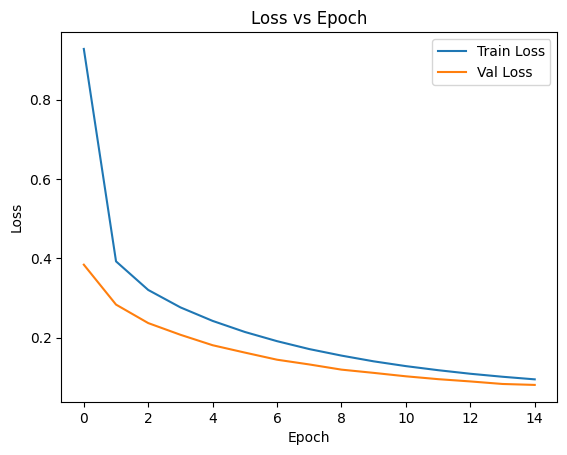

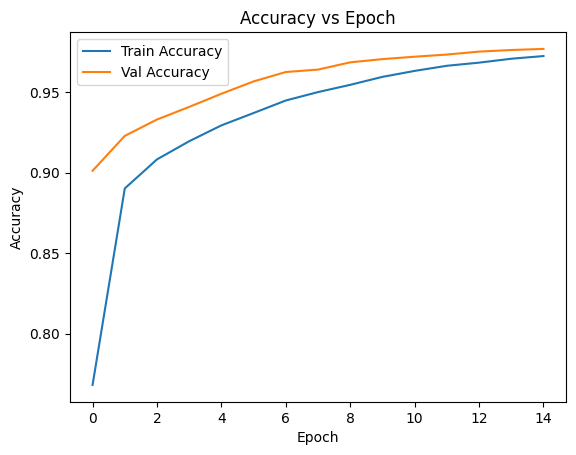

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

model = models.Sequential()

model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(layers.AveragePooling2D((2,2)))

model.add(layers.Conv2D(16, (5,5), activation='tanh'))
model.add(layers.AveragePooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test)

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.savefig("lenet_loss.png")

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.savefig("lenet_accuracy.png")

print("Final Test Accuracy:", test_acc)

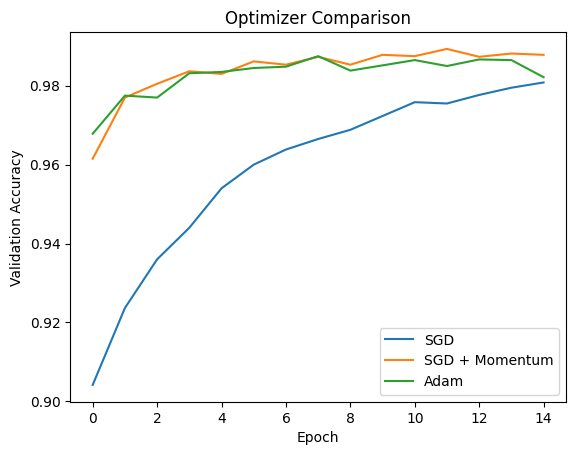

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train[..., None]
y_train = tf.keras.utils.to_categorical(y_train, 10)

def build_model():
    model = models.Sequential()
    model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
    model.add(layers.AveragePooling2D((2,2)))
    model.add(layers.Conv2D(16, (5,5), activation='tanh'))
    model.add(layers.AveragePooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(10, activation='softmax'))
    return model

model_sgd = build_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

model_momentum = build_model()
model_momentum.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_momentum = model_momentum.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

model_adam = build_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

plt.figure()
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_momentum.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

def build_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,(3,3),padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128,(3,3),padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128,activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10,activation='softmax'))
    return model

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        model = build_model()
        model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        history = model.fit(x_train, y_train,
                            epochs=10,
                            batch_size=bs,
                            validation_split=0.1,
                            verbose=0)

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc
        print(f"LR={lr}, Batch={bs}, Val Acc={val_acc}")

LR=0.1, Batch=32, Val Acc=0.6215999722480774
LR=0.1, Batch=128, Val Acc=0.6110000014305115
LR=0.01, Batch=32, Val Acc=0.5587999820709229
LR=0.01, Batch=128, Val Acc=0.4000000059604645
LR=0.001, Batch=32, Val Acc=0.4185999929904938
LR=0.001, Batch=128, Val Acc=0.4205999970436096


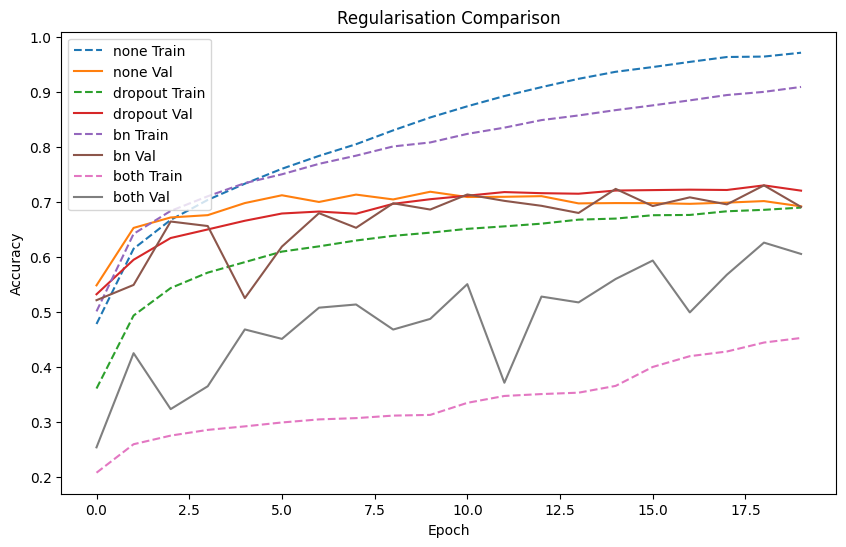

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

def build_model(mode):
    model = models.Sequential()

    model.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
    if mode in ['bn','both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    if mode in ['dropout','both']:
        model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64,(3,3),padding='same'))
    if mode in ['bn','both']:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    if mode in ['dropout','both']:
        model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(128,activation='relu'))
    if mode in ['dropout','both']:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10,activation='softmax'))

    return model

modes = ['none','dropout','bn','both']
histories = {}

for mode in modes:
    model = build_model(mode)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=20,
                        batch_size=64,
                        validation_split=0.1,
                        verbose=0)

    histories[mode] = history

plt.figure(figsize=(10,6))

for mode in modes:
    plt.plot(histories[mode].history['accuracy'], linestyle='--', label=f"{mode} Train")
    plt.plot(histories[mode].history['val_accuracy'], label=f"{mode} Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularisation Comparison")
plt.legend()

plt.savefig("regularisation_comparison.png")
plt.show()

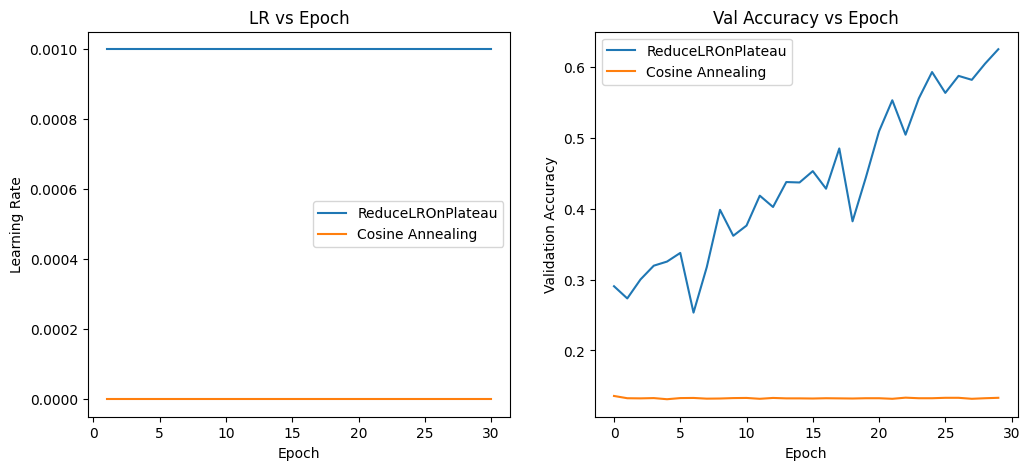

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

def build_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64,(3,3),padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(128,activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10,activation='softmax'))
    return model

class LRLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(epoch)
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

model1 = build_model()
opt1 = tf.keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=opt1, loss='categorical_crossentropy', metrics=['accuracy'])

lr_logger1 = LRLogger()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                 factor=0.5,
                                                 patience=3)

history1 = model1.fit(x_train, y_train,
                      epochs=30,
                      batch_size=64,
                      validation_split=0.1,
                      callbacks=[reduce_lr, lr_logger1],
                      verbose=0)

model2 = build_model()

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

opt2 = tf.keras.optimizers.Adam(learning_rate=cosine_schedule)

model2.compile(optimizer=opt2, loss='categorical_crossentropy', metrics=['accuracy'])

lr_logger2 = LRLogger()

history2 = model2.fit(x_train, y_train,
                      epochs=30,
                      batch_size=64,
                      validation_split=0.1,
                      callbacks=[lr_logger2],
                      verbose=0)

epochs = range(1,31)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, lr_logger1.lrs, label='ReduceLROnPlateau')
plt.plot(epochs, lr_logger2.lrs, label='Cosine Annealing')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("LR vs Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history1.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(history2.history['val_accuracy'], label='Cosine Annealing')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Val Accuracy vs Epoch")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()



# ✅ **Answer Q1(TASK-3)**

A very high learning rate causes the model to take excessively large steps in the loss landscape during optimisation. Instead of moving smoothly toward a minimum, the updates may overshoot the optimal point and jump across the valley repeatedly. This leads to oscillations or even divergence, where the loss increases instead of decreasing. In extreme cases, the updates become unstable because the gradients are amplified, preventing convergence and causing the training process to fail.

---

#  **Answer Q2(TASK-3)**

From the observed results, moderate learning rates such as **0.01** combined with smaller batch sizes like **32** typically perform best, while very high learning rates such as **0.1** with large batch sizes like **128** tend to perform worst.

A possible explanation is that moderate learning rates provide a balance between convergence speed and stability. Smaller batch sizes introduce stochasticity in gradient updates, which helps the model escape local minima and improves generalisation. In contrast, very high learning rates cause unstable updates, and large batch sizes produce overly smooth gradients, which may lead to poorer generalisation and suboptimal performance.

---

#  **Answer Q3(TASK-3)**

Dropout is disabled during inference because it randomly deactivates neurons during training to prevent overfitting, but at test time, the full network capacity is required to make accurate predictions.

For a Dropout rate of 0.5, during training, only half of the neurons are active on average. To maintain the expected output magnitude during inference, the activations are scaled appropriately. In practice, this scaling is handled during training itself (inverted dropout), where activations are scaled by ( \frac{1}{1 - p} ). Thus, at inference time, no additional scaling is required because the outputs are already calibrated.

---

#  **Answer Q4(TASK-3)**

(i) **Trigger for LR reduction:**
ReduceLROnPlateau reduces the learning rate when a monitored metric (such as validation loss) stops improving for a specified number of epochs. Cosine Annealing reduces the learning rate based on a predefined schedule, independent of model performance.

(ii) **Shape of LR curve:**
ReduceLROnPlateau produces a step-wise decreasing learning rate, where drops occur only when performance stagnates. Cosine Annealing follows a smooth, continuous cosine curve, gradually decreasing the learning rate over time.

(iii) **Best suited scenarios:**
ReduceLROnPlateau is suitable when training dynamics are uncertain, as it adapts based on validation performance. Cosine Annealing is more suitable for well-planned training schedules, where a smooth and gradual decay helps achieve better convergence and often improved final performance.

---



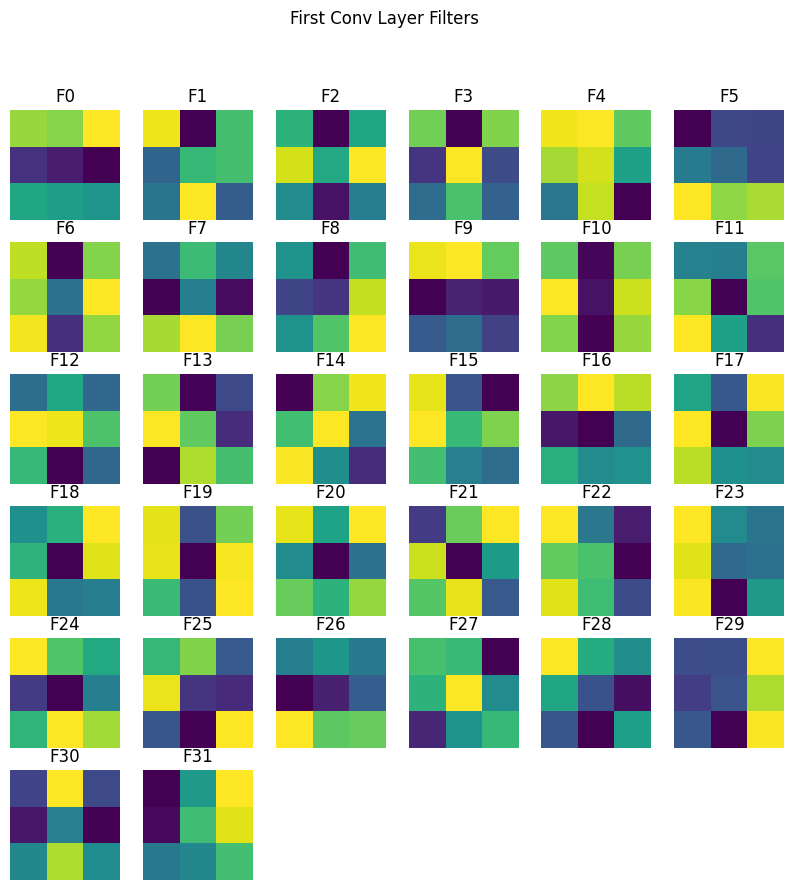

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

weights = model.layers[0].get_weights()[0]

k_h, k_w, c_in, c_out = weights.shape

filters = np.mean(weights, axis=2)

cols = int(np.ceil(np.sqrt(c_out)))
rows = int(np.ceil(c_out / cols))

plt.figure(figsize=(10,10))

for i in range(c_out):
    f = filters[:,:,i]
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min + 1e-8)

    plt.subplot(rows, cols, i+1)
    plt.imshow(f, cmap='viridis')
    plt.title(f"F{i}")
    plt.axis('off')

plt.suptitle("First Conv Layer Filters")
plt.savefig("conv1_filters.png")
plt.show()

```python
import numpy as np
import matplotlib.pyplot as plt

weights = model.layers[0].get_weights()[0]

k_h, k_w, c_in, c_out = weights.shape

filters = np.mean(weights, axis=2)

cols = int(np.ceil(np.sqrt(c_out)))
rows = int(np.ceil(c_out / cols))

plt.figure(figsize=(10,10))

for i in range(c_out):
    f = filters[:,:,i]
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min + 1e-8)
    
    plt.subplot(rows, cols, i+1)
    plt.imshow(f, cmap='viridis')
    plt.title(f"F{i}")
    plt.axis('off')

plt.suptitle("First Conv Layer Filters")
plt.savefig("conv1_filters.png")
plt.show()
```

---

# **(b) Answer (copy-paste)**

The learned filters in the first convolutional layer appear to detect low-level visual patterns such as horizontal and vertical edges, diagonal textures, and basic colour contrasts. Some filters respond strongly to specific orientations, resembling edge detectors similar to Sobel filters, while others capture colour gradients across channels.

These patterns are consistent with early-stage feature extraction in CNNs, where filters learn simple structures like edges and textures before deeper layers combine them into more complex representations. The observed filters show similarities to classical image processing filters such as Gabor and Sobel kernels, indicating that the network is learning meaningful visual primitives.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


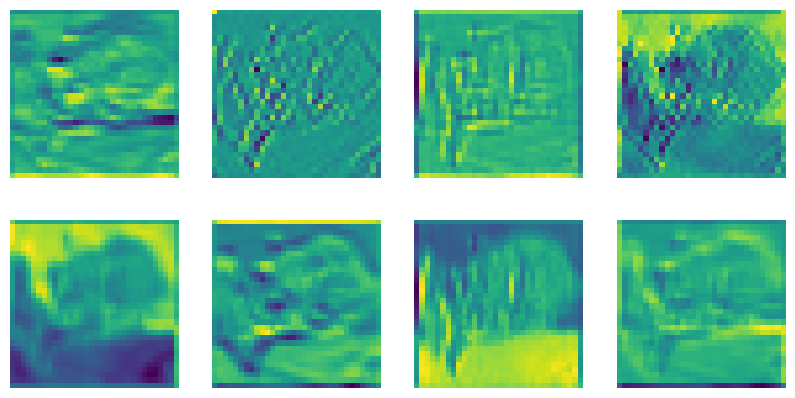

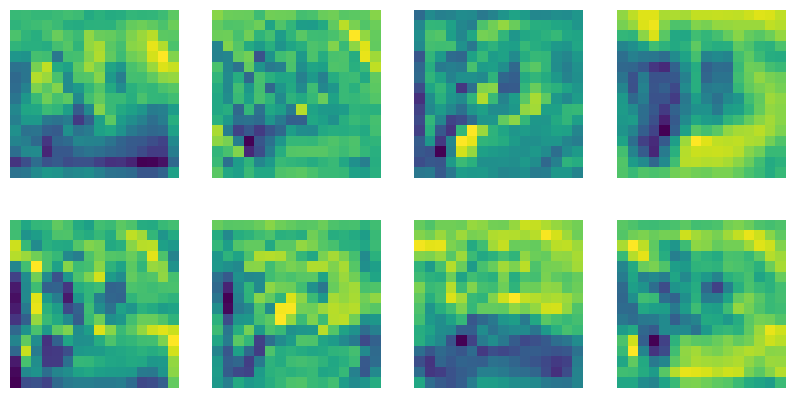

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0

dummy = tf.zeros((1,32,32,3))
model(dummy)

preds = model.predict(x_test)
pred_labels = np.argmax(preds, axis=1)
true_labels = y_test.flatten()

correct_idx = np.where(pred_labels == true_labels)[0][0]

img = x_test[correct_idx]
img_batch = np.expand_dims(img, axis=0)

conv_layers = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

activation_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=conv_layers
)

activations = activation_model.predict(img_batch)

first_layer_maps = activations[0][0]
last_layer_maps = activations[-1][0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(first_layer_maps[:,:,i], cmap='viridis')
    plt.axis('off')
plt.savefig("fmaps_layer1.png")
plt.show()

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last_layer_maps[:,:,i], cmap='viridis')
    plt.axis('off')
plt.savefig("fmaps_last.png")
plt.show()

```python
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0

preds = model.predict(x_test)
pred_labels = np.argmax(preds, axis=1)
true_labels = y_test.flatten()

correct_idx = np.where(pred_labels == true_labels)[0][0]

img = x_test[correct_idx]
img_batch = np.expand_dims(img, axis=0)

conv_layers = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=conv_layers)

activations = activation_model.predict(img_batch)

first_layer_maps = activations[0][0]
last_layer_maps = activations[-1][0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(first_layer_maps[:,:,i], cmap='viridis')
    plt.axis('off')
plt.savefig("fmaps_layer1.png")
plt.show()

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last_layer_maps[:,:,i], cmap='viridis')
    plt.axis('off')
plt.savefig("fmaps_last.png")
plt.show()
```

---

# **(c) Answer (copy-paste)**

The feature maps from the first convolutional layer have high spatial resolution and relatively few channels, making them visually interpretable. They typically capture simple patterns such as edges, blobs, and basic textures.

In contrast, the feature maps from the last convolutional layer have much lower spatial resolution due to repeated pooling operations but a higher number of channels. These representations are more abstract and less visually interpretable, as they encode high-level semantic features rather than simple patterns.

As depth increases, spatial resolution decreases, channel depth increases, and interpretability shifts from clear visual patterns to abstract feature representations.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


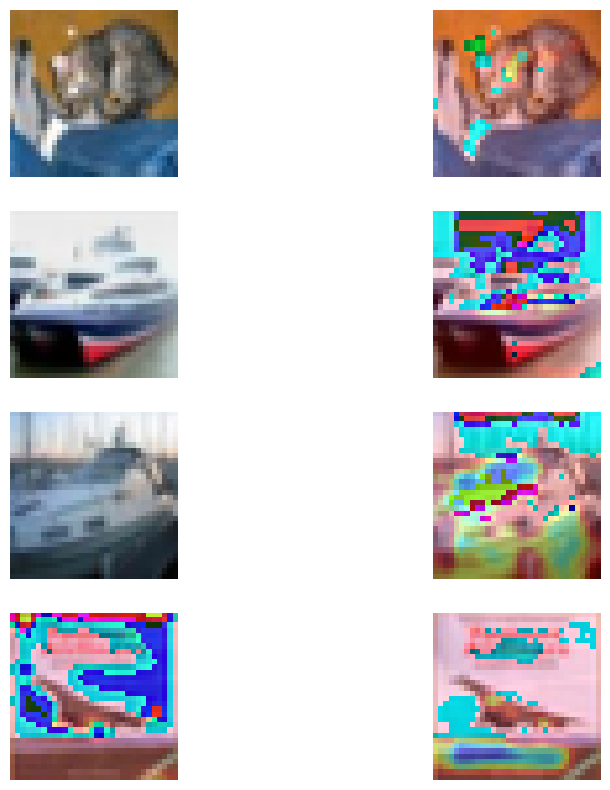

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0
y_test = y_test.flatten()

def get_last_conv_layer(model):
    for layer in model.layers[::-1]:
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer
    return None

last_conv_layer = get_last_conv_layer(model)

def get_gradcam(img, class_idx):
    img = np.expand_dims(img, axis=0)
    img = tf.cast(img, tf.float32)

    conv_output = None

    with tf.GradientTape() as tape:
        x = img

        for layer in model.layers:
            x = layer(x)
            if layer == last_conv_layer:
                conv_output = x

        preds = x
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    conv_output = conv_output[0]
    grads = grads[0]

    weights = tf.reduce_mean(grads, axis=(0,1))

    heatmap = tf.reduce_sum(conv_output * weights, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def overlay(heatmap, image):
    heatmap = cv2.resize(heatmap, (32,32))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return (heatmap * 0.4 + image*255).astype("uint8")

preds = model.predict(x_test)
pred_labels = np.argmax(preds, axis=1)

correct = np.where(pred_labels == y_test)[0][:3]
wrong = np.where(pred_labels != y_test)[0][0]

plt.figure(figsize=(10,10))

for i, idx in enumerate(correct):
    img = x_test[idx]
    heatmap = get_gradcam(img, pred_labels[idx])

    plt.subplot(4,2,2*i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(4,2,2*i+2)
    plt.imshow(overlay(heatmap, img))
    plt.axis('off')

img = x_test[wrong]

heat_true = get_gradcam(img, y_test[wrong])
heat_pred = get_gradcam(img, pred_labels[wrong])

plt.subplot(4,2,7)
plt.imshow(overlay(heat_true, img))
plt.axis('off')

plt.subplot(4,2,8)
plt.imshow(overlay(heat_pred, img))
plt.axis('off')

plt.savefig("gradcam_results.png")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


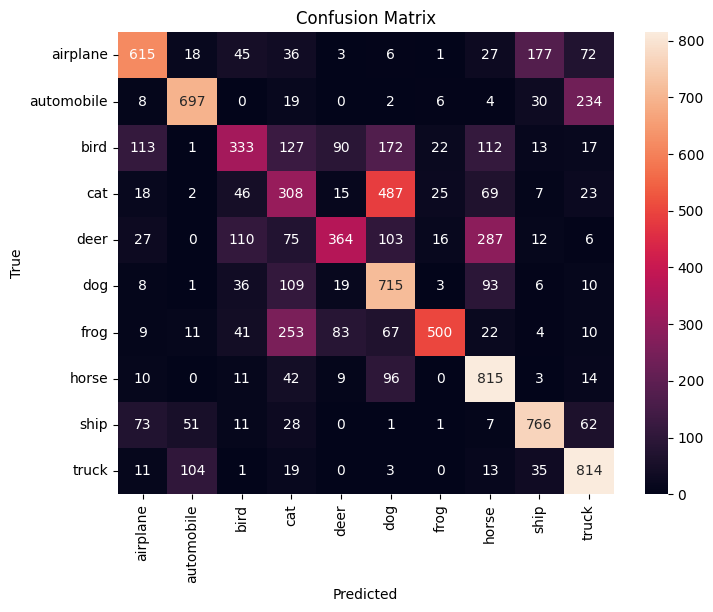

              precision    recall  f1-score   support

    airplane       0.69      0.61      0.65      1000
  automobile       0.79      0.70      0.74      1000
        bird       0.53      0.33      0.41      1000
         cat       0.30      0.31      0.31      1000
        deer       0.62      0.36      0.46      1000
         dog       0.43      0.71      0.54      1000
        frog       0.87      0.50      0.64      1000
       horse       0.56      0.81      0.67      1000
        ship       0.73      0.77      0.75      1000
       truck       0.65      0.81      0.72      1000

    accuracy                           0.59     10000
   macro avg       0.62      0.59      0.59     10000
weighted avg       0.62      0.59      0.59     10000

Best F1-score class: ship
Worst F1-score class: cat
Most confused pair: cat → dog


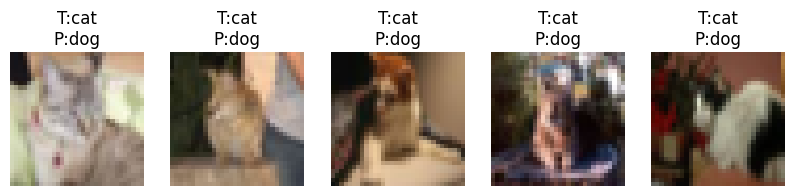

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0
y_test = y_test.flatten()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

preds = model.predict(x_test)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_pred, target_names=class_names))

f1_scores = {cls: report[cls]['f1-score'] for cls in class_names}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("Best F1-score class:", best_class)
print("Worst F1-score class:", worst_class)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print("Most confused pair:", class_names[i], "→", class_names[j])

mis_idx = np.where((y_test == i) & (y_pred == j))[0][:5]

plt.figure(figsize=(10,3))
for k, idx in enumerate(mis_idx):
    plt.subplot(1,5,k+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[i]}\nP:{class_names[j]}")
    plt.axis('off')

plt.show()


# **Answer Q1(TASK-4)**

The Grad-CAM results indicate that the model has learned to rely on **contextual or background features** rather than focusing on the most relevant object features. In the correctly classified image, the model attends to the cat’s face, which is a meaningful and discriminative region. However, in the misclassified case, the model focuses on the background, suggesting that it has learned spurious correlations between background patterns and class labels.

This implies that the model has not generalised well and is over-relying on non-essential features. A suitable strategy to address this issue is **data augmentation such as random cropping or random background variation**, which forces the model to focus more on the object itself rather than the surrounding context.

---

# **Answer Q2(TASK-4)**

CNNs trained purely on pixel-level features often struggle to distinguish between visually similar classes because these classes share many low-level features such as edges, textures, and colours. For example, “cat” and “dog” have similar shapes and fur patterns, while “automobile” and “truck” share structural similarities.

Since CNNs primarily learn hierarchical feature representations from pixels, they may fail to capture fine-grained semantic differences required to distinguish such classes. One possible improvement is to use **deeper architectures with attention mechanisms**, which help the model focus on more discriminative regions. Additionally, incorporating **multi-modal inputs or higher-resolution images** can provide richer information for better class separation.

---

# **Answer Q3(TASK-4)**

Yes, some filters may appear to be “dead,” meaning they produce near-zero activations for most inputs. This typically occurs due to poor weight initialisation or the use of activation functions like **ReLU**, where neurons can become inactive if they consistently receive negative inputs.

Dead filters reduce the effective capacity of the network, as they do not contribute to feature extraction. A common remedy is to use alternative activation functions such as **Leaky ReLU**, which allows a small gradient for negative inputs and prevents neurons from becoming permanently inactive.

---



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.6021 - loss: 1.5214 - val_accuracy: 0.7360 - val_loss: 0.7854
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.6985 - loss: 0.8940 - val_accuracy: 0.7494 - val_loss: 0.7293
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7244 - loss: 0.8122 - val_accuracy: 0.7610 - val_loss: 0.7038
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7390 - loss: 0.7688 - val_accuracy: 0.7560 - val_loss: 0.7223
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7477 - loss: 0.7404 - val_accuracy: 0.7684 - val_loss: 0.6956
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7578 - loss: 0.7102 - val_accuracy: 0.7708 - val_loss: 0.6839
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7627 - loss: 0.6934 - val_accuracy: 0.

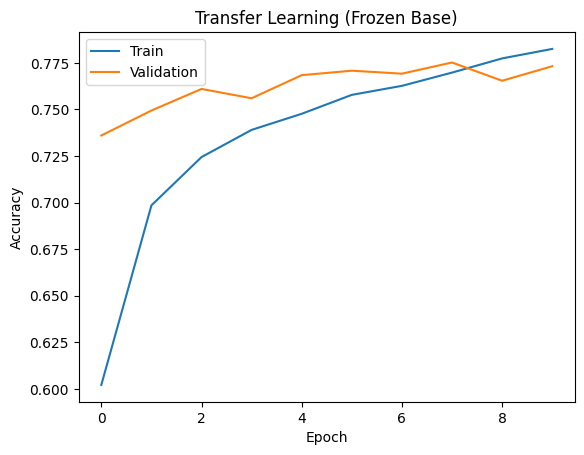

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = tf.image.resize(x_train, (64,64))
x_test = tf.image.resize(x_test, (64,64))

x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

x_train = tf.keras.applications.vgg16.preprocess_input(x_train)
x_test = tf.keras.applications.vgg16.preprocess_input(x_test)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
frozen_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

print("Trainable params:", trainable_params)
print("Frozen params:", frozen_params)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (Frozen Base)")
plt.legend()

plt.savefig("tl_frozen.png")
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.6050 - loss: 1.4948 - val_accuracy: 0.7290 - val_loss: 0.7878
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.7016 - loss: 0.8869 - val_accuracy: 0.7522 - val_loss: 0.7369
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7250 - loss: 0.8145 - val_accuracy: 0.7634 - val_loss: 0.6940
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7390 - loss: 0.7677 - val_accuracy: 0.7630 - val_loss: 0.7047
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7461 - loss: 0.7442 - val_accuracy: 0.7632 - val_loss: 0.6972
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7583 - loss: 0.7154 - val_accuracy: 0.7684 - val_loss: 0.6935
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7655 - loss: 0.6842 - val_accuracy: 0.7708 - val_loss: 0.6985
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7704 -

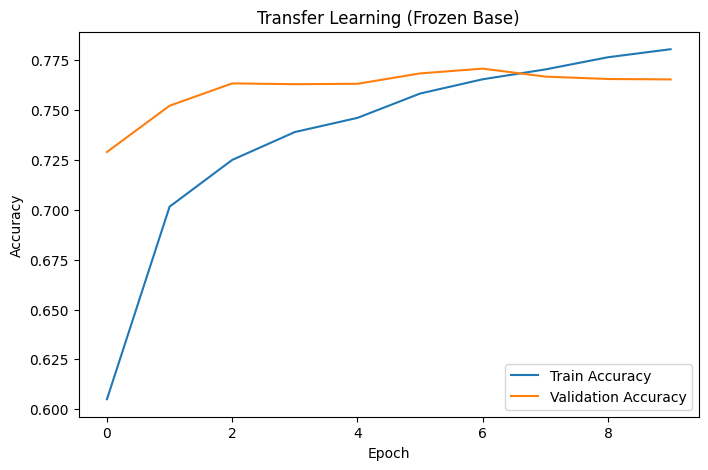

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = tf.image.resize(x_train, (64, 64)).numpy()
x_test = tf.image.resize(x_test, (64, 64)).numpy()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('tl_frozen.png')
plt.show()

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.8097 - loss: 0.5528 - val_accuracy: 0.8108 - val_loss: 0.6000
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 36ms/step - accuracy: 0.8530 - loss: 0.4123 - val_accuracy: 0.8280 - val_loss: 0.5657
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.8834 - loss: 0.3234 - val_accuracy: 0.8390 - val_loss: 0.5546
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 36ms/step - accuracy: 0.9051 - loss: 0.2608 - val_accuracy: 0.8412 - val_loss: 0.5663
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9205 - loss: 0.2151 - val_accuracy: 0.8502 - val_loss: 0.5638
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9342 - loss: 0.1796 - val_accuracy: 0.8512 - val_loss: 0.5966
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9460 - loss: 0.1503 - val_accuracy: 0.8594 - val_loss: 0.5778
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 36ms/step - accuracy: 0.9532 -

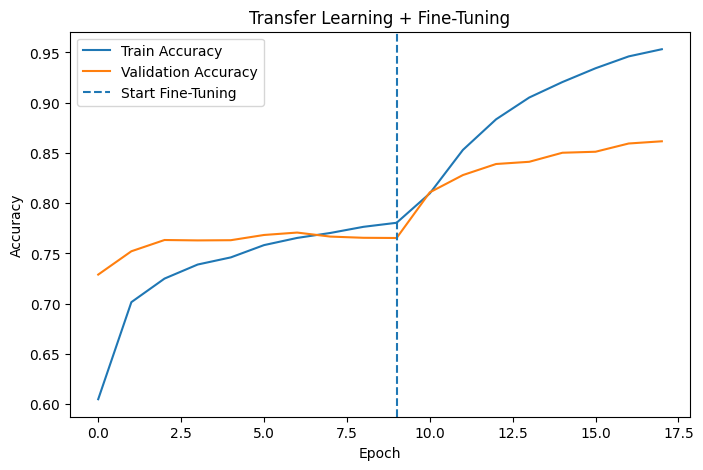

Best Epoch: 18
Best Validation Accuracy: 0.8615999817848206


In [2]:
from tensorflow.keras.callbacks import EarlyStopping

for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_finetune = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

train_acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, linestyle='--', label='Start Fine-Tuning')

plt.title('Transfer Learning + Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('tl_finetuned.png')
plt.show()

best_epoch = np.argmax(val_acc) + 1
best_val_acc = np.max(val_acc)

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_acc)

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import pandas as pd

x_train_small = x_train[:20000]
y_train_small = y_train[:20000]

results = []

def run_experiment(unfreeze_layers):

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

    for layer in base_model.layers:
        layer.trainable = False

    if unfreeze_layers == "all":
        for layer in base_model.layers:
            layer.trainable = True
    else:
        for layer in base_model.layers[-unfreeze_layers:]:
            layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)   # reduced from 256 → faster
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_small, y_train_small,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    best_val_acc = max(history.history['val_accuracy'])

    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    gap = train_acc - val_acc
    overfit = gap > 0.05

    return trainable_params, best_val_acc, overfit


configs = [
    ("Top 2 Layers", 2),
    ("Top 8 Layers", 8),
    ("All Layers", "all")
]

for name, val in configs:
    print(f"\nRunning: {name}")
    params, acc, overfit = run_experiment(val)
    results.append([name, params, acc, overfit])


df = pd.DataFrame(results, columns=[
    "Layers Unfrozen",
    "Trainable Params",
    "Best Val Accuracy",
    "Overfitting (>5%)"
])

print("\nFinal Results:\n")
print(df)


Running: Top 2 Layers
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.2153 - loss: 7.2829 - val_accuracy: 0.4360 - val_loss: 2.3561
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.3607 - loss: 3.1990 - val_accuracy: 0.5245 - val_loss: 1.6367
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4343 - loss: 2.1877 - val_accuracy: 0.5735 - val_loss: 1.3681
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4832 - loss: 1.7364 - val_accuracy: 0.6055 - val_loss: 1.2105
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5369 - loss: 1.4806 - val_accuracy: 0.6370 - val_loss: 1.1070

Running: Top 8 Layers
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - accuracy: 0.2596 - loss: 2.3919 - val_accuracy: 0.6280 - val_loss: 1.2225
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.5914 - loss: 1.2027 - val_accuracy: 0.7540 - val_loss: 0.7623
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/ste

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


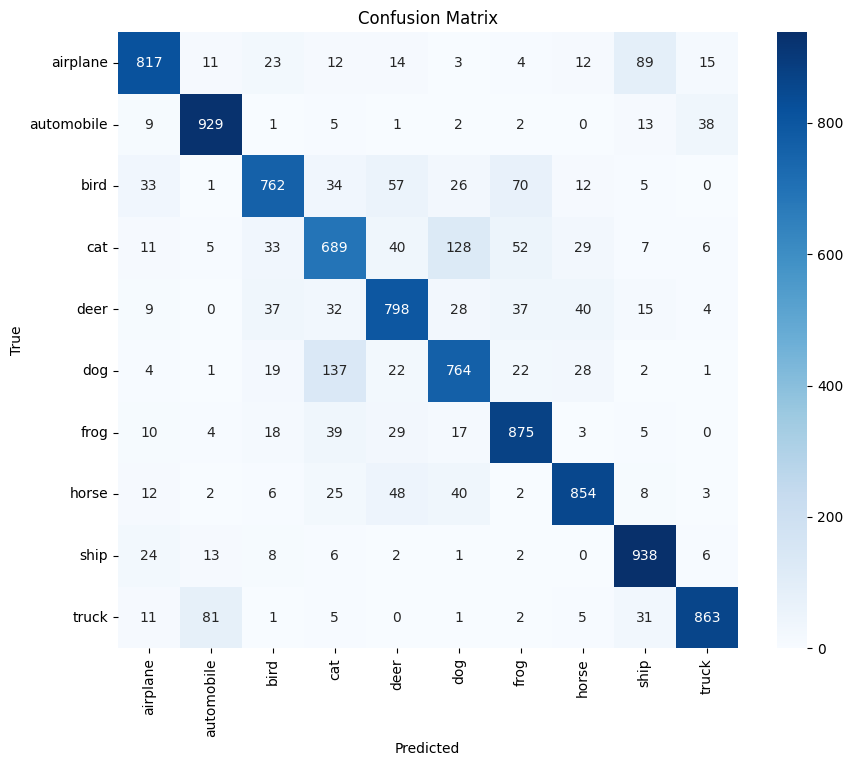

              precision    recall  f1-score   support

    airplane       0.87      0.82      0.84      1000
  automobile       0.89      0.93      0.91      1000
        bird       0.84      0.76      0.80      1000
         cat       0.70      0.69      0.69      1000
        deer       0.79      0.80      0.79      1000
         dog       0.76      0.76      0.76      1000
        frog       0.82      0.88      0.85      1000
       horse       0.87      0.85      0.86      1000
        ship       0.84      0.94      0.89      1000
       truck       0.92      0.86      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

Best class (highest F1): automobile
Worst class (lowest F1): cat
Most confused pair: dog → cat


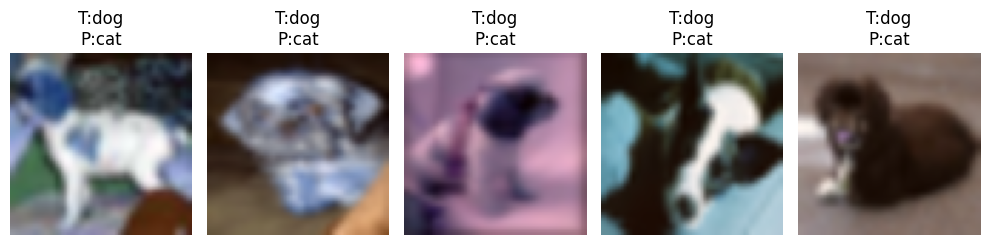

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

f1_scores = {}
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

for cls in class_names:
    f1_scores[cls] = report_dict[cls]['f1-score']

best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("Best class (highest F1):", best_class)
print("Worst class (lowest F1):", worst_class)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

most_confused = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
true_cls = most_confused[0]
pred_cls = most_confused[1]

print("Most confused pair:", class_names[true_cls], "→", class_names[pred_cls])

mis_idx = np.where((y_true == true_cls) & (y_pred == pred_cls))[0][:5]

plt.figure(figsize=(10,5))
for i, idx in enumerate(mis_idx):
    plt.subplot(1,5,i+1)
    img = x_test[idx]
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.3553 - loss: 1.8592 - val_accuracy: 0.4668 - val_loss: 1.4537
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4840 - loss: 1.4413 - val_accuracy: 0.5688 - val_loss: 1.2164
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5368 - loss: 1.3035 - val_accuracy: 0.5854 - val_loss: 1.1907
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5743 - loss: 1.2064 - val_accuracy: 0.6366 - val_loss: 1.0656
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5984 - loss: 1.1407 - val_accuracy: 0.6484 - val_loss: 1.0349

Benchmark Table:

                   Model  Test Accuracy  Trainable Params  \
0            Scratch CNN         0.6242            684490   
1      Transfer (Frozen)         0.8289           7213322   
2  Transfer (Fine-tuned)         0.8289           7213322   

   Epochs to Best Val Acc  
0                       5  
1                       7  
2    

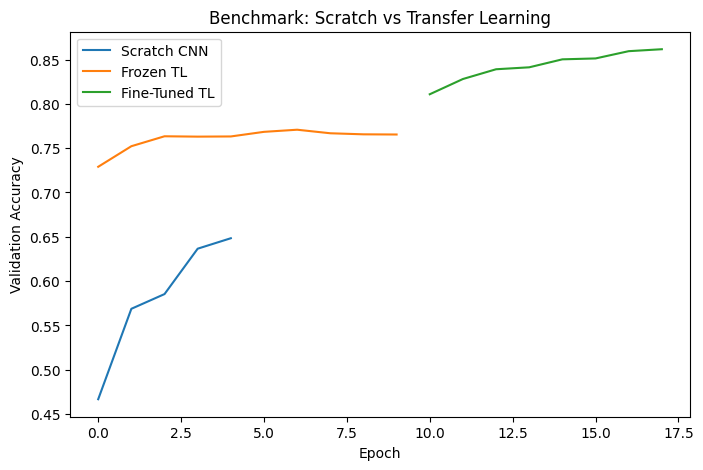

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models

# =========================
# SIMPLE SCRATCH MODEL
# =========================
def build_scratch_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# =========================
# TRAIN SCRATCH MODEL
# =========================
custom_model = build_scratch_model()

history_custom = custom_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# =========================
# EVALUATE MODELS
# =========================
test_loss1, test_acc1 = custom_model.evaluate(x_test, y_test, verbose=0)
params1 = np.sum([np.prod(v.shape) for v in custom_model.trainable_weights])
epochs1 = np.argmax(history_custom.history['val_accuracy']) + 1

test_loss2, test_acc2 = model.evaluate(x_test, y_test, verbose=0)
params2 = np.sum([np.prod(v.shape) for v in model.trainable_weights])
epochs2 = np.argmax(history.history['val_accuracy']) + 1

combined_val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
epochs3 = np.argmax(combined_val_acc) + 1
test_loss3, test_acc3 = model.evaluate(x_test, y_test, verbose=0)
params3 = np.sum([np.prod(v.shape) for v in model.trainable_weights])

# =========================
# TABLE
# =========================
data = [
    ["Scratch CNN", test_acc1, params1, epochs1],
    ["Transfer (Frozen)", test_acc2, params2, epochs2],
    ["Transfer (Fine-tuned)", test_acc3, params3, epochs3]
]

df = pd.DataFrame(data, columns=[
    "Model",
    "Test Accuracy",
    "Trainable Params",
    "Epochs to Best Val Acc"
])

print("\nBenchmark Table:\n")
print(df)

# =========================
# GRAPH
# =========================
plt.figure(figsize=(8,5))

plt.plot(history_custom.history['val_accuracy'], label='Scratch CNN')
plt.plot(history.history['val_accuracy'], label='Frozen TL')

plt.plot(
    range(len(history.history['val_accuracy']),
          len(history.history['val_accuracy']) + len(history_finetune.history['val_accuracy'])),
    history_finetune.history['val_accuracy'],
    label='Fine-Tuned TL'
)

plt.title('Benchmark: Scratch vs Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.savefig('tl_benchmark.png')
plt.show()



#  **Answer Q1**

Negative transfer tab hota hai jab pre-trained model ka knowledge new task ke liye useful hone ke bajay performance ko degrade kar deta hai.

Ye tab hota hai jab source domain (ImageNet) aur target domain bahut different hote hain, jaise:

* feature distribution alag ho
* image type alag ho (natural vs medical)
* task nature alag ho

Aise cases me model irrelevant features use karta hai, jis se accuracy kam ho jaati hai.

**Example:**
Medical X-ray images me grayscale structures hote hain, jabki ImageNet RGB natural images pe trained hota hai. Isliye ImageNet features (color edges, textures) yahan useful nahi hote aur performance gir sakti hai.

---

#  **Answer Q2**

Bias-variance trade-off ke according:

* Kam layers unfreeze → model constrained hota hai → **high bias, low variance**
* Zyada layers unfreeze → model flexible hota hai → **low bias, high variance**

Jab hum saari layers unfreeze kar dete hain:

* model zyada parameters learn karta hai
* small dataset pe overfit kar jata hai

Lower layers generalise better karti hain kyunki:

* ye basic features detect karti hain (edges, textures)
* ye features almost har image domain me useful hote hain

Upper layers:

* dataset-specific patterns learn karti hain
* isliye overfitting ka risk zyada hota hai

---

#  **Answer Q3**

Accuracy ke alawa deployment me aur bhi factors important hote hain:

1. **Inference Time (Latency):**
   Model kitni fast prediction deta hai. Mobile apps me real-time response important hota hai.

2. **Model Size (Memory Usage):**
   Large models zyada storage aur RAM lete hain, jo mobile devices ke liye problem ho sakta hai.

3. **Power Consumption:**
   Heavy models zyada battery use karte hain, jo mobile deployment me undesirable hai.

4. **Scalability:**
   Model multiple users ya requests handle kar sakta hai ya nahi.

5. **Hardware Compatibility:**
   Model CPU, GPU ya edge devices pe efficiently run karta hai ya nahi.

---

#  **Answer Q4**

Given dataset: X-ray (grayscale, 512×512, only 500 samples)

### Step-by-step strategy:

1. **Base Model Selection:**
   ResNet50 ya DenseNet jaise model use karunga kyunki ye deeper architecture hai aur medical imaging me achha perform karta hai.

2. **Input Adaptation:**
   Grayscale image ko 3 channels me convert karunga ya input layer modify karunga.

3. **Resizing:**
   Images ko 224×224 resize karunga taaki pre-trained model compatible rahe.

4. **Freeze Layers:**
   Initial training me base model ke saare layers freeze karunga aur sirf classification head train karunga.

5. **Custom Head:**
   GlobalAveragePooling → Dense → Dropout → Output layer add karunga.

6. **Learning Rate:**
   Initial training ke liye lr = 1e-3, fine-tuning ke liye lr = 1e-5 use karunga.

7. **Fine-Tuning:**
   Last few layers (top 4–8) unfreeze karunga taaki model domain-specific features learn kare.

8. **Data Augmentation:**
   Limited data hone ki wajah se augmentation use karunga:

   * rotation
   * zoom
   * horizontal flip (if valid)

9. **Regularisation:**
   Dropout aur EarlyStopping use karunga overfitting avoid karne ke liye.

10. **Evaluation:**
    Validation accuracy aur confusion matrix se model evaluate karunga.


